<a href="https://colab.research.google.com/github/aniray2908/satellite-esg-risk-engine/blob/main/experiments/python/ceri/ceri_v7_feature_interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CERI v7 — Feature Interpretability

This notebook analyzes how engineered exposure features influence the
Corporate Environmental Risk Index (CERI) score.

Previous stages of the framework established:

- satellite-derived exposure signal extraction
- composite exposure scoring (CERI v2 baseline)
- optimization and governance validation
- deployment tier logic
- statistical robustness validation
- predictive modeling validation

The objective of this stage is to **interpret the behavior of the scoring system** by examining relationships between engineered features and the composite exposure score.

The analysis focuses on three exposure features:

- **F1 — Exposure Intensity**
- **F2 — Vegetation Suppression**
- **F3 — Exposure Persistence**

Understanding these relationships helps explain how environmental exposure signals translate into the final exposure score.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/drive/MyDrive/ceri_v2_feature_layer.csv")

df

,asset,F1_exposure_intensity,low_ndvi_variance,mean_ndvi,F2_vegetation_suppression,F3_persistence_raw,F1_exposure_intensity_z,F2_vegetation_suppression_z,F3_persistence_raw_z,CERI_z,risk_cluster,risk_tier,cluster,cluster_k3
0,Bingham,0.999922,2.805335e-09,0.021179,0.978821,1.000000e+00,0.629904,0.421693,0.519958,0.545452,0,High Risk,0,2
1,Carajás,0.937332,2.050342e-03,0.035150,0.964850,4.877238e-07,0.213303,0.268879,-1.499415,-0.112568,0,High Risk,0,0
2,Gevra,0.684294,6.057728e-05,0.193744,0.806256,9.704564e-01,-1.470942,-1.465874,0.460299,-1.083173,1,Moderate Risk,1,1
3,Grasberg,0.999596,8.161065e-07,-0.011148,1.011148,9.996033e-01,0.627735,0.775302,0.519157,0.650290,0,High Risk,0,2


## Feature Correlation Analysis

The first step is to examine correlations between engineered exposure features.

Strong correlations could indicate redundant signals, while low correlations suggest that each feature captures a distinct aspect of environmental exposure.

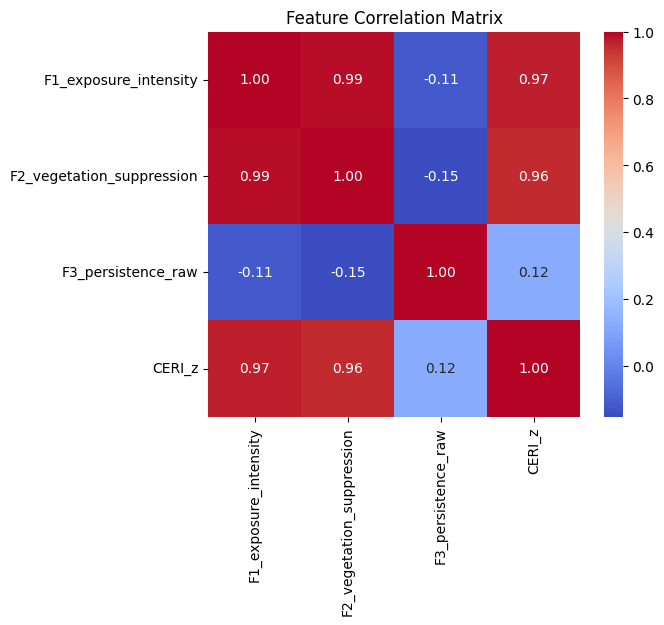

In [3]:
corr = df[[
    "F1_exposure_intensity",
    "F2_vegetation_suppression",
    "F3_persistence_raw",
    "CERI_z"
]].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

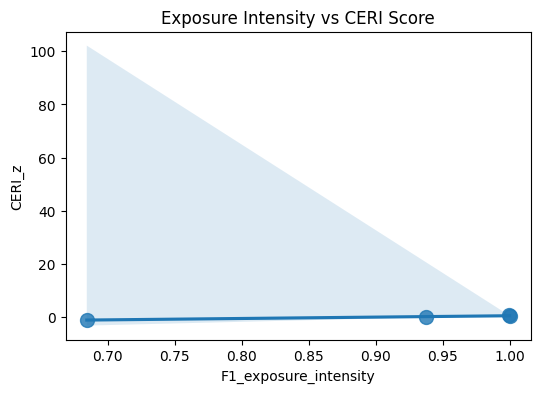

In [8]:
plt.figure(figsize=(6,4))

sns.regplot(
    data=df,
    x="F1_exposure_intensity",
    y="CERI_z",
    scatter_kws={"s":100}
)

plt.title("Exposure Intensity vs CERI Score")

plt.show()

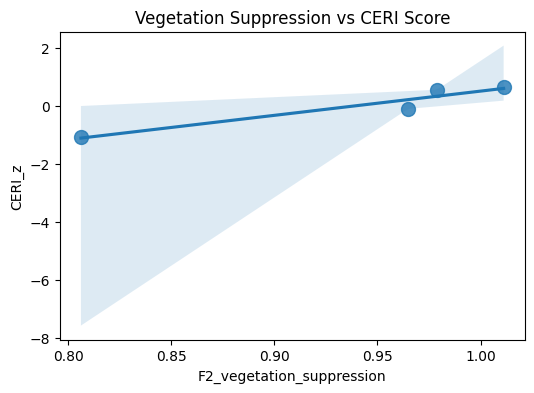

In [9]:
plt.figure(figsize=(6,4))

sns.regplot(
    data=df,
    x="F2_vegetation_suppression",
    y="CERI_z",
    scatter_kws={"s":100}
)

plt.title("Vegetation Suppression vs CERI Score")

plt.show()

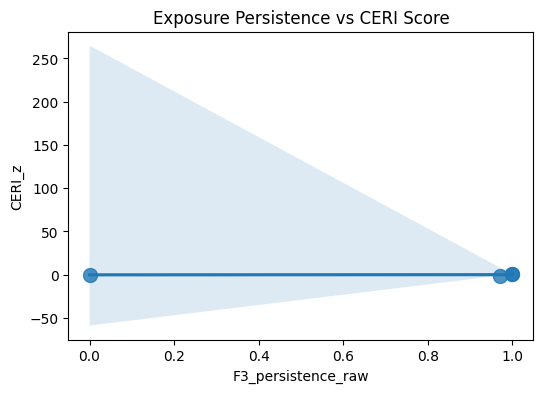

In [10]:
plt.figure(figsize=(6,4))

sns.regplot(
    data=df,
    x="F3_persistence_raw",
    y="CERI_z",
    scatter_kws={"s":100}
)

plt.title("Exposure Persistence vs CERI Score")

plt.show()

## Feature Sensitivity Analysis

To better understand model behavior, we simulate how the CERI score changes as individual features vary.

This helps illustrate how sensitive the composite score is to changes in environmental exposure signals.

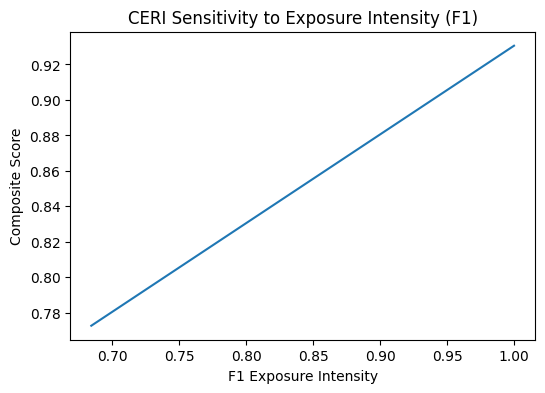

In [7]:
f1_range = np.linspace(
    df["F1_exposure_intensity"].min(),
    df["F1_exposure_intensity"].max(),
    50
)

w1, w2, w3 = 0.5, 0.3, 0.2

baseline_f2 = df["F2_vegetation_suppression"].mean()
baseline_f3 = df["F3_persistence_raw"].mean()

scores = []

for f1 in f1_range:

    score = (
        w1 * f1 +
        w2 * baseline_f2 +
        w3 * baseline_f3
    )

    scores.append(score)

plt.figure(figsize=(6,4))

plt.plot(f1_range, scores)

plt.title("CERI Sensitivity to Exposure Intensity (F1)")
plt.xlabel("F1 Exposure Intensity")
plt.ylabel("Composite Score")

plt.show()

## Feature Contribution Weights

The CERI score is computed as a weighted combination of the standardized exposure features.

The baseline scoring weights reflect the conceptual importance of each signal:

- Exposure Intensity (F1)
- Vegetation Suppression (F2)
- Exposure Persistence (F3)

Visualizing these weights provides an interpretable view of how each feature contributes to the composite exposure score.

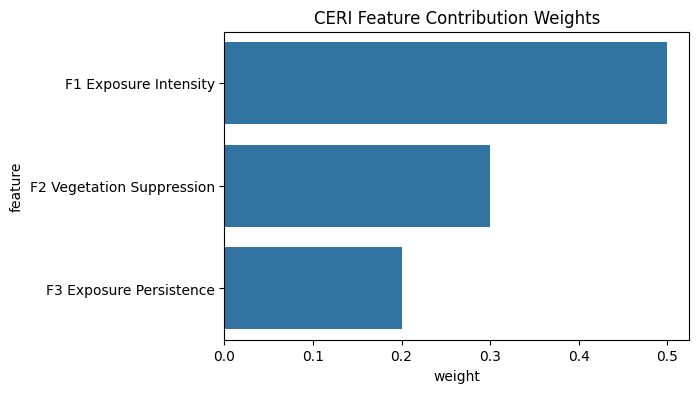

In [11]:
weights = pd.DataFrame({
    "feature": [
        "F1 Exposure Intensity",
        "F2 Vegetation Suppression",
        "F3 Exposure Persistence"
    ],
    "weight": [0.5, 0.3, 0.2]
})

plt.figure(figsize=(6,4))

sns.barplot(
    data=weights,
    x="weight",
    y="feature"
)

plt.title("CERI Feature Contribution Weights")

plt.show()

## Interpretation

The interpretability analysis highlights several key observations:

- Exposure intensity (F1) exhibits a strong positive relationship with the composite exposure score.
- Vegetation suppression (F2) contributes additional separation between assets with similar exposure intensity.
- Exposure persistence (F3) influences relative ranking primarily when stability differences are large.

Together, these features capture complementary aspects of environmental exposure:

- **spatial intensity**
- **vegetation suppression**
- **temporal persistence**

The results confirm that the engineered features behave consistently with the conceptual design of the exposure scoring framework.

This stage improves transparency and interpretability of the CERI model while maintaining its simplicity and reproducibility.